### **3.2 Baseline Model**

In this practical, you'll build your first baseline models for time series forecasting. A baseline model is a simple, intuitive approach to prediction - often based on straightforward rules or heuristics - and acts as a reference point for evaluating more complex models later on.

Using quarterly earnings data from Johnson & Johnson, you will explore how features like trend and seasonality affect forecasts and learn to construct several naive forecasting models.

The dataset for this practical is the `JohnsonAndJohnson.csv` file.

This activity has been adapted from [this book](https://www.manning.com/books/time-series-forecasting-in-python-book)

**Step 1: Import Libraries and Read the Data**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

In [3]:
df = pd.read_csv('./data/JohnsonAndJohnson_4.csv')
df.head()

,time,JohnsonJohnson
0,1/1/1960,0.71
1,1/4/1960,0.63
2,2/7/1960,0.85
3,1/10/1960,0.44
4,1/1/1961,0.61


**Step 2: Check if the time attribute is DateTime, otherwise convert to DateTime datatype**

We will do the following:

- check the data type

- convert to datatime data type (if needed)

- check the head() and tail() to inspect the data values

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   time            84 non-null     str    
 1   JohnsonJohnson  84 non-null     float64
dtypes: float64(1), str(1)
memory usage: 1.4 KB


In [5]:
df["time"] = pd.to_datetime(df["time"], dayfirst=True)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   time            84 non-null     datetime64[us]
 1   JohnsonJohnson  84 non-null     float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 1.4 KB


In [6]:
df.head()

,time,JohnsonJohnson
0,1960-01-01,0.71
1,1960-04-01,0.63
2,1960-07-02,0.85
3,1960-10-01,0.44
4,1961-01-01,0.61


In [7]:
df.tail()

,time,JohnsonJohnson
79,1979-10-01,9.99
80,1980-01-01,16.20
81,1980-04-01,14.67
82,1980-07-02,16.02
83,1980-10-01,11.61


Our data time is now `Year-Month-Day`

**Step 3: Let's look at the data**

We will plot the data.

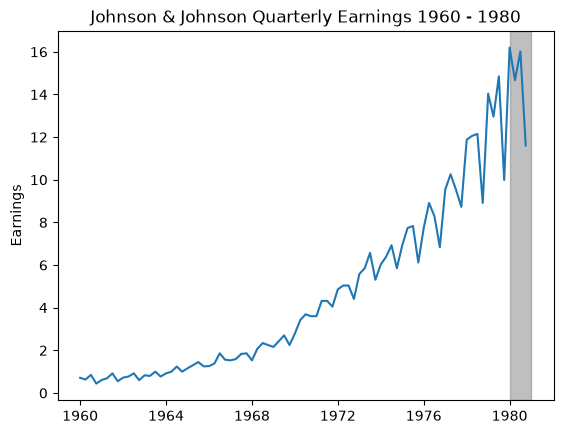

In [8]:
# Create a figure and axis object
fig, ax = plt.subplots()

# Plot the time series using the datetime index
ax.plot(df["time"], df["JohnsonJohnson"])
ax.set_ylabel('Earnings')
ax.set_title('Johnson & Johnson Quarterly Earnings 1960 - 1980')

# Shadow the window we want to predict (last year, i.e. 1980)
ax.axvspan(datetime(1980, 1, 1), datetime(1980, 12, 31), color='gray', alpha=0.5)
plt.show()

**Step 4: Split to train/test**

We are going to split the data into two parts: one for training the model and one for testing how well it works. Since we want to forecast one year ahead, we will use all the data from 1960 to 1979 to train the model. The data from 1980 will be used to check how accurate our predictions are.

To split the data, we will keep everything except the last four rows for training, and use the last four rows as our test set.

**Since the data is quarterly (one row per quarter), four data points represent one full year** - which matches our forecast horizon. The next code block shows how to do this.

In [9]:
# Split the data to keep the last year as testing data
train = df[:-4]
test = df[-4:]

**Step 5: Forecasting using Historical Mean**

Now we are ready to build our **baseline model**. We will start with the simplest possible approach: predicting the **average value** from the training set for every point in the test set.

To calculate the average, we will use the **Numpy** library - a fast and efficient tool for scientific computing in Python that works smoothly with Pandas DataFrames.

In [10]:
# compute for the mean from 1960 to 1979
historical_mean = train["JohnsonJohnson"].mean()
historical_mean

np.float64(4.308499987499999)

We will naively forecast this value for each quarter of 1980.

In [11]:
# Create a new DataFrame to compare actual vs predicted values using the historical mean
pred_hist_mean = pd.DataFrame()

# Add time column from the test set
pred_hist_mean["time"] = test["time"]

# Add actual values from the test set
pred_hist_mean["JohnsonJohnson"] = test["JohnsonJohnson"]

# Add predicted values using the historical mean
pred_hist_mean["pred"] = historical_mean

# Display the DataFrame
pred_hist_mean

,time,JohnsonJohnson,pred
80,1980-01-01,16.20,4.3085
81,1980-04-01,14.67,4.3085
82,1980-07-02,16.02,4.3085
83,1980-10-01,11.61,4.3085


**Step 6: Use MAPE to calculate error**

Mean Absolute Percentage Error (MAPE) is a measure of prediction accuracy for forecasting methods that is easy to interpret and independent of the scale of our data. This means that whether we are working with two-digit values or six-digit values, the MAPE will always be expreessed as a percentage. MAPE returns the percentage of how much the forecast values deviate from the observed or actual values on average, whether the prediction was higher or lower than the observed values.

We will define a MAPE function that takes in two vectors: y_true for the actual values observed in the test set and y_pred for the forecast values. In this case, because numpy allows us to work with arrays, we will not need a loop to sum all the values. We can simply subtract the y_pred array from the y_true array and divide by y_true to get the percentage error. Then we can take the absolute value. After that, we take the mean of the result, which will take care of summing up each value in the vector and dividing by the number of predictions.

For details for the formula, you can check it [here](https://www.statisticshowto.com/mean-absolute-percentage-error-mape/).

In [12]:
def mape(y_true, y_pred):
    """
    Calculate the Mean Absolute Percentage Error (MAPE) between true and predicted values.
    
    Parameters:
    y_true (array-like): True values.
    y_pred (array-like): Predicted values.
    
    Returns:
    float: MAPE value.
    """
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [13]:
# Compute the MAPE of our baseline model
mape_value = mape(pred_hist_mean["JohnsonJohnson"], pred_hist_mean["pred"])
mape_value

np.float64(70.00752579965119)

**What does this mean?**

This means that our baseline deviates by 70% on average from the observed quarterly earnings of Johnson & Johnson in 1980.

Let's visualise to understand MAPE

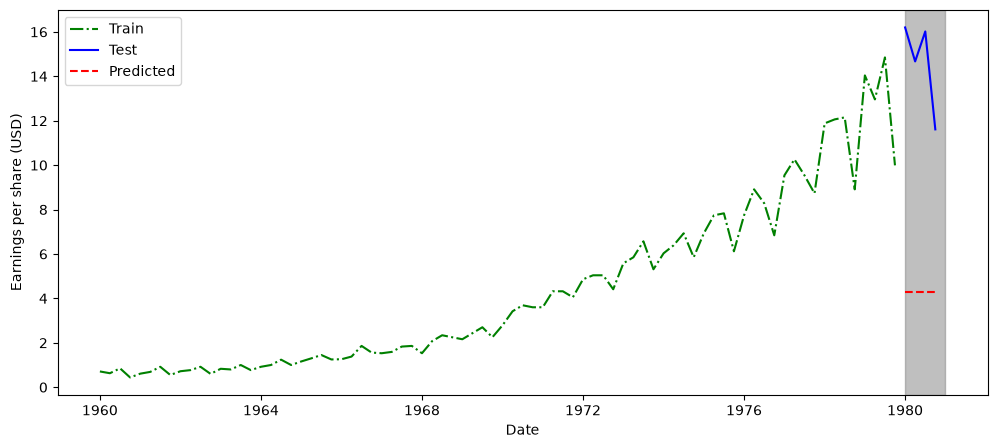

In [14]:
fig,ax = plt.subplots(figsize=(12,5))

ax.plot(train["time"], train["JohnsonJohnson"], "g-.", label="Train")
ax.plot(test["time"], test["JohnsonJohnson"], "b-", label="Test")
ax.plot(pred_hist_mean["time"], pred_hist_mean["pred"], "r--", label="Predicted")

ax.set_xlabel("Date")
ax.set_ylabel("Earnings per share (USD)")

# Shadow the window we want to predict (last year, i.e. 1980)
ax.axvspan(datetime(1980, 1, 1), datetime(1980, 12, 31), color='gray', alpha=0.5)
ax.legend()
plt.show()

You can see the small red line (predicted value) and the blue line (actual value).

---

**Takeaways: Using the historical Mean as a Baseline**

- Using the **mean of the training data** is a simple and common baseline for forecasting. It provides a reference point to compare more advanced models against.

- This method is most useful when the time series is **stable**, with no clear trend or seasonality - for example, in white noise or flat production metrics.

- However, in time series with **trends** (values increasing or decreasing over time) or **seasonal patterns** (regular ups and downs), the mean is too simplistic.

- In our case, the data shows both trend and possible seasonality, so the mean will likely produce poor forecasts. It doesn't adapt to changes over time and will systematically **underestimate** or **overestimate** depending on where the test period falls.

- Still, it is a valuable **benchmark**: if a more complex model can't do better than this, it is probably not worth using.

---


**Step 7: Forecast using previous year's mean**

From the previous baseline it is seen that earlier values do not seem to be predictive of future values in the long term because of the positive trend component in our dataset. We will use the mean of the last year in our training set to forecast the following year.

In [15]:
# Compute last year's mean: we need to change our training set
last_year_mean = train["JohnsonJohnson"].iloc[-4:].mean()
last_year_mean

np.float64(12.96)

In [16]:
# Create the new column which contains last year's mean
pred_last_year_mean = pd.DataFrame()
pred_last_year_mean["time"] = test["time"]
pred_last_year_mean["JohnsonJohnson"] = test["JohnsonJohnson"]
pred_last_year_mean["pred"] = last_year_mean

pred_last_year_mean

,time,JohnsonJohnson,pred
80,1980-01-01,16.20,12.96
81,1980-04-01,14.67,12.96
82,1980-07-02,16.02,12.96
83,1980-10-01,11.61,12.96


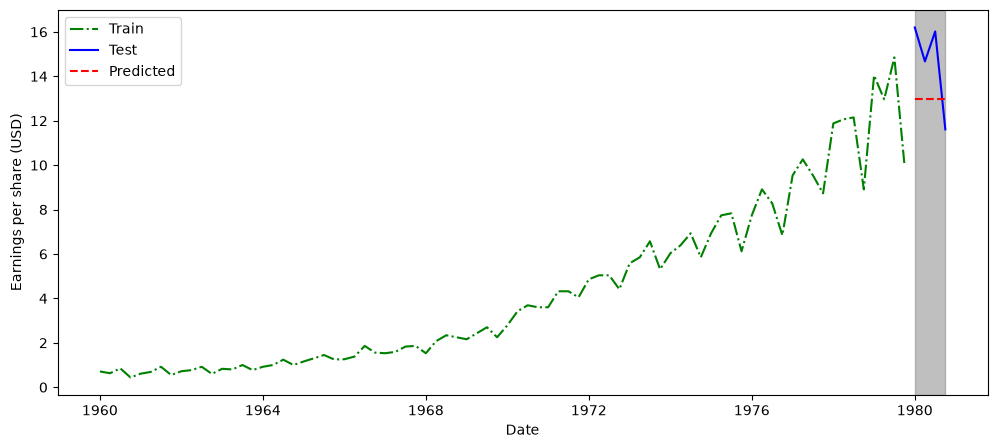

In [17]:
# Plot again to visualise the predicted versus the training set
fig,ax = plt.subplots(figsize=(12,5))

ax.plot(train["time"], train["JohnsonJohnson"], "g-.", label="Train")
ax.plot(test["time"], test["JohnsonJohnson"], "b-", label="Test")
ax.plot(pred_last_year_mean["time"], pred_last_year_mean["pred"], "r--", label="Predicted")

ax.set_xlabel("Date")
ax.set_ylabel("Earnings per share (USD)")

# Shadow the window we want to predict (last year, i.e. 1980)
ax.axvspan(test["time"].min(), test["time"].max(), color='gray', alpha=0.5)
ax.legend()
plt.show()


In [18]:
# Compute the MAPE of the new model
mape_value = mape(pred_last_year_mean["JohnsonJohnson"], pred_last_year_mean["pred"])
mape_value

np.float64(15.5963680725103)

**What does this mean?**

We decreased the MAPE from 70.0% to 15.6%. We can see that in this baseline model that the future values likely depend on past values that are not too far back.

**Step 8: Forecast using the last known value**

The premise is that using the last known value of the training set as a baseline model will give us an even better forecast.

In [19]:
# Get the last known value
last = train["JohnsonJohnson"].iloc[-1]
last

np.float64(9.99)

In [20]:
# Create the new column which contains the last known value
pred_last = pd.DataFrame()
pred_last["time"] = test["time"]
pred_last["JohnsonJohnson"] = test["JohnsonJohnson"]
pred_last["pred"] = last

pred_last

,time,JohnsonJohnson,pred
80,1980-01-01,16.20,9.99
81,1980-04-01,14.67,9.99
82,1980-07-02,16.02,9.99
83,1980-10-01,11.61,9.99


In [21]:
# Compute the MAPE using the last known value as the prediction
mape_value = mape(pred_last["JohnsonJohnson"], pred_last["pred"])
mape_value

np.float64(30.457277908606535)

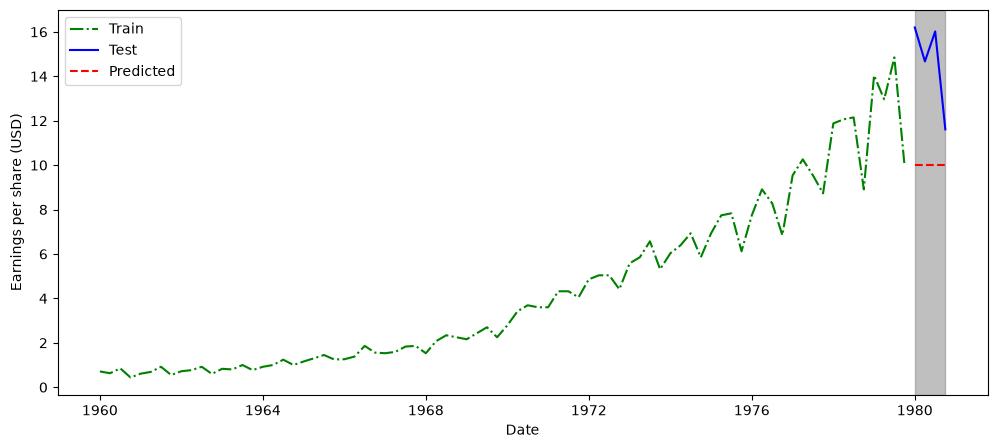

In [22]:
# Plot again to visualise using the last known value as the prediction
fig,ax = plt.subplots(figsize=(12,5))

ax.plot(train["time"], train["JohnsonJohnson"], "g-.", label="Train")
ax.plot(test["time"], test["JohnsonJohnson"], "b-", label="Test")
ax.plot(pred_last["time"], pred_last["pred"], "r--", label="Predicted")

ax.set_xlabel("Date")
ax.set_ylabel("Earnings per share (USD)")

# Shadow the window we want to predict (last year, i.e. 1980)
ax.axvspan(test["time"].min(), test["time"].max(), color='gray', alpha=0.5)
ax.legend()
plt.show()


**Using the last known value from the training set as a baseline forecast**, we obtain a **MAPE of 30.46%**. This baseline performs better than our first naive forecast (historical mean), but is less accurate than the **last season mean** model (our second naive baseline).

**Step 9: Naive Seasonal Forecast**

Using the last known value does not take the seasonality into account, so we need to use another naive forecasting technique to see if we can produce a better baseline.

The seasonal naive forecast assumes that the most recent observed seasonal cycle will repeat itself into the future. In our dataset, a full seasonal cycle spans **four quarters**, so we use the values from **each quarter of 1979* to predict the corresponding quarters in **1980**.

Specifically:

- Q1 1980 is predicted using EPS from Q1 1979

- Q2 1980 is predicted using EPS from Q2 1979

...and so on for Q3 and Q4.

This method works well when the time series shows **regular seasonal patterns**.

In Python, we can implement this by extracting the **last four observations from the training set** (representing the final seasonal cycle) and assigning them to the forecast period. The following code adds a pred_last_season column to store these predictions from the seasonal naive method.

In [23]:
# Get the last four values of train set which we know are the last four quarters of 1979
pred_naive_seasonal = pd.DataFrame()
pred_naive_seasonal = test
pred_naive_seasonal["pred"] = train["JohnsonJohnson"].iloc[-4:].values
pred_naive_seasonal

,time,JohnsonJohnson,pred
80,1980-01-01,16.20,14.04
81,1980-04-01,14.67,12.96
82,1980-07-02,16.02,14.85
83,1980-10-01,11.61,9.99


In [26]:
# Compute the MAPE using the last four values of the train set as the prediction
mape_value = mape(pred_naive_seasonal["JohnsonJohnson"], pred_naive_seasonal["pred"])
print(f"MAPE: {mape_value:.2f}%")

MAPE: 11.56%


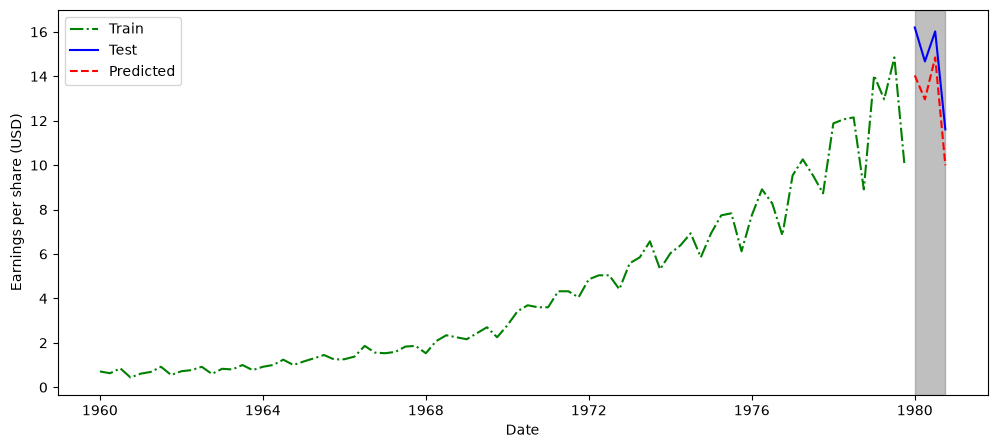

In [25]:
# Plot again to visualise using the last four values of the train set as the prediction
fig,ax = plt.subplots(figsize=(12,5))

ax.plot(train["time"], train["JohnsonJohnson"], "g-.", label="Train")
ax.plot(test["time"], test["JohnsonJohnson"], "b-", label="Test")
ax.plot(pred_naive_seasonal["time"], pred_naive_seasonal["pred"], "r--", label="Predicted")

ax.set_xlabel("Date")
ax.set_ylabel("Earnings per share (USD)")

# Shadow the window we want to predict (last year, i.e. 1980)
ax.axvspan(test["time"].min(), test["time"].max(), color='gray', alpha=0.5)
ax.legend()
plt.show()


The **seasonal naive forecast** closely matches the pattern observed in the test set and produced the lowest MAPE among the baseline models. This result highlights that the **seasonality in the data has a significant influence on future values**, and accounting for it leads to more accurate forecasts.

Clearly, incorporating seasonality - even with a simple model - can greatly improve forecast performance in datasets with strong, repeating seasonal patterns.

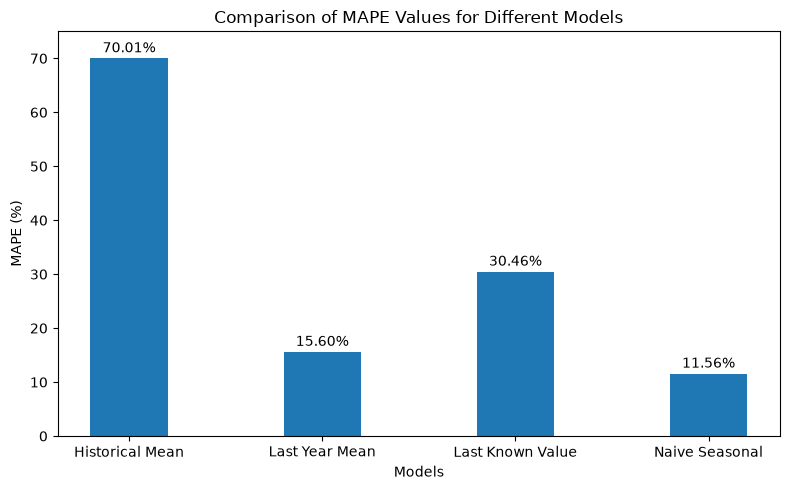

In [27]:
# Compare the MAPE values of the three models
fig, ax = plt.subplots(figsize=(8, 5))

x = ["Historical Mean", "Last Year Mean", "Last Known Value", "Naive Seasonal"]
y = [mape(pred_hist_mean["JohnsonJohnson"], pred_hist_mean["pred"]),
     mape(pred_last_year_mean["JohnsonJohnson"], pred_last_year_mean["pred"]),
     mape(pred_last["JohnsonJohnson"], pred_last["pred"]),
     mape(pred_naive_seasonal["JohnsonJohnson"], pred_naive_seasonal["pred"])]

ax.bar(x, y, width=0.4)
ax.set_xlabel("Models")
ax.set_ylabel("MAPE (%)")
ax.set_title("Comparison of MAPE Values for Different Models")
ax.set_ylim(0, max(y) + 5)  # Set y-axis limit for better visualization

# Rounded MAPE values on top of the bars
for i, v in enumerate(y):
    ax.text(i, v + 0.5, f"{v:.2f}%", ha='center', va='bottom')

plt.tight_layout()
plt.show()

**Key Takeaways: Baseline Models in Time Series Forecasting**

- **Time series forecasting** typically begins with a **baseline model**, which serves as a **benchmark** to evaluate the performance of more complex models.

- A **baseline model** is a **simple and intuitive solution**, often relying on basic **heuristics** or **summary statistics**, such as the mean or the last observed value.

- **MAPE** (*Mean Absolute Percentage Error*) is a commonly used error metric that shows the average percentage difference between predicted and actual values. It provides an easy-to-interpret measure of forecast accuracy.

- There are various ways to construct baseline models. In this activity, you explored:

    - The **historical mean**

    - The **last season mean**

    - The **last known value**

    - The **seasonal naive forecast** (repeating the last full seasonal cycle)